In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("D:/DL/student_health_prediction/train.csv")
df

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [3]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [5]:
df.describe

<bound method NDFrame.describe of             id health_condition  sleep_duration  heart_rate    bmi  \
0            0        unhealthy            5.22        70.6  25.66   
1            1          at-risk            5.53        71.3  25.84   
2            2        unhealthy            5.29        75.4  24.54   
3            3        unhealthy            4.70        77.2  23.13   
4            4          at-risk            7.23        73.4  28.44   
...        ...              ...             ...         ...    ...   
690083  690083          at-risk            6.31        69.7  24.11   
690084  690084          at-risk            5.78        54.0  26.36   
690085  690085              fit            7.64        85.7  21.91   
690086  690086          at-risk            6.74        73.0  18.73   
690087  690087          at-risk            5.55        69.3  24.38   

        calorie_expenditure  step_count  exercise_duration  water_intake  \
0                    2174.0      1326.0          

In [6]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [7]:
df.isnull().mean()

id                         0.000000
health_condition           0.000000
sleep_duration             0.110129
heart_rate                 0.011351
bmi                        0.020139
calorie_expenditure        0.076589
step_count                 0.020166
exercise_duration          0.010000
water_intake               0.063002
diet_type                  0.010000
stress_level               0.120001
sleep_quality              0.084527
physical_activity_level    0.053067
smoking_alcohol            0.041418
gender                     0.030971
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop("id", axis = 1, inplace= True)

In [10]:
numeric_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df[numeric_cols].describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000
mean,6.992311,75.096544,22.985027,2227.227258,8620.793728,38.757941,2.187374
std,1.146529,8.128577,2.456669,333.982029,3889.725112,14.668434,0.501911
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.300000,69.500000,21.380000,2068.000000,5460.000000,29.300000,1.870000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.680000,80.600000,24.630000,2438.000000,12089.000000,49.300000,2.470000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [11]:
categorical_cols = [
    "diet_type",
    "sleep_quality",
    "stress_level",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode())


In [25]:
cat_cols = [
    "stress_level",
    "sleep_quality",
    "physical_activity_level"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
for col in categorical_cols:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)

diet_type:
<StringArray>
['veg', 'non-veg', 'balanced', nan]
Length: 4, dtype: str
----------------------------------------
sleep_quality:
<StringArray>
['average', 'poor', nan, 'good']
Length: 4, dtype: str
----------------------------------------
stress_level:
<StringArray>
['high', 'low', nan, 'medium']
Length: 4, dtype: str
----------------------------------------
physical_activity_level:
<StringArray>
['sedentary', 'moderate', 'active', nan]
Length: 4, dtype: str
----------------------------------------
smoking_alcohol:
<StringArray>
['yes', 'occasional', nan, 'no']
Length: 4, dtype: str
----------------------------------------
gender:
<StringArray>
['female', 'other', 'male', nan]
Length: 4, dtype: str
----------------------------------------


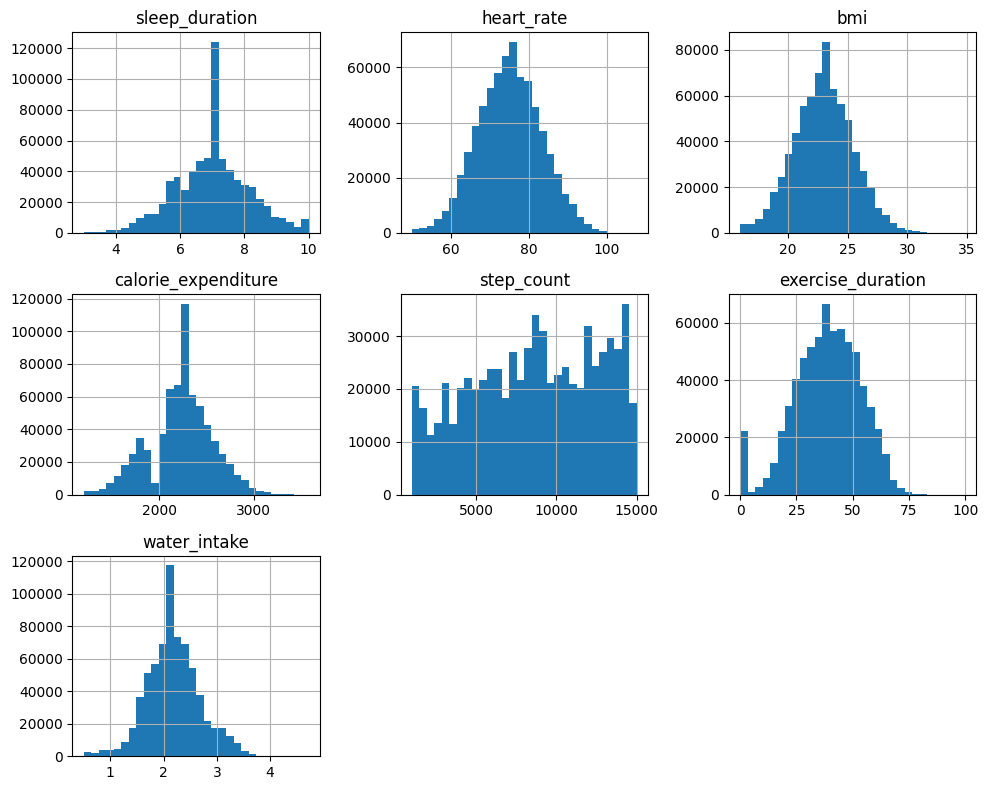

In [13]:
import matplotlib.pyplot as plt
df[numeric_cols].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

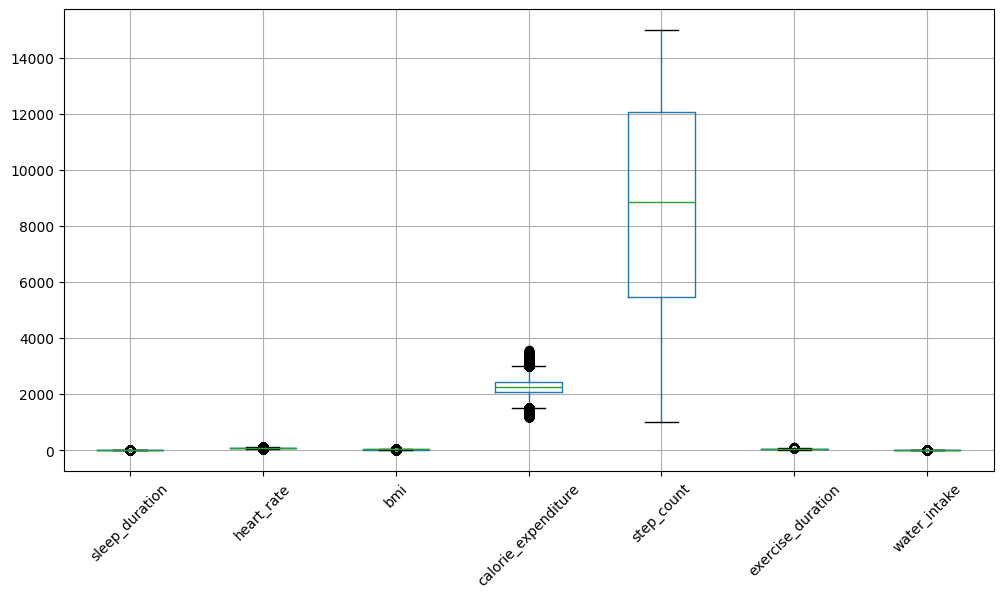

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()

plt.xticks(rotation=45)
plt.show()

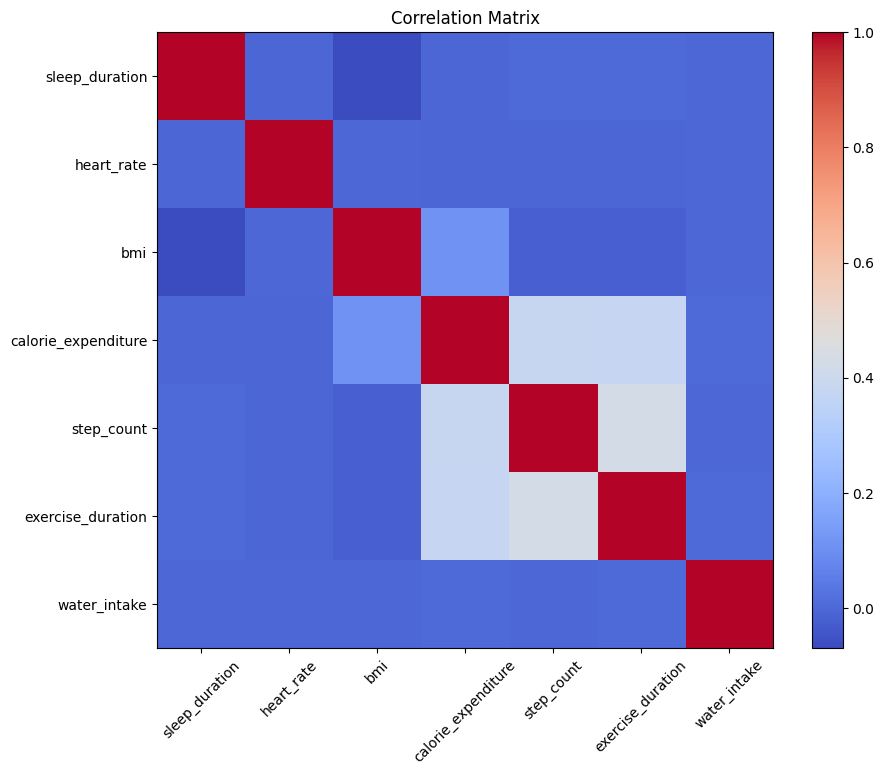

In [15]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)

plt.title('Correlation Matrix')
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

# Target
le = LabelEncoder()
df["health_condition"] = le.fit_transform(df["health_condition"])

# Ordinal columns
df["stress_level"] = df["stress_level"].map({
    "low":0,
    "medium":1,
    "high":2
})

df["sleep_quality"] = df["sleep_quality"].map({
    "poor":0,
    "average":1,
    "good":2,
    "excellent":3
})

df["physical_activity_level"] = df["physical_activity_level"].map({
    "sedentary":0,
    "moderate":1,
    "active":2
})

# One-hot encode nominal columns
df = pd.get_dummies(
    df,
    columns=["diet_type", "gender", "smoking_alcohol"],
    dtype=int
)

In [17]:
df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,diet_type_balanced,diet_type_non-veg,diet_type_veg,gender_female,gender_male,gender_other,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes
0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2.0,1.0,0.0,0,0,1,1,0,0,0,0,1
1,0,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0.0,1.0,1.0,0,1,0,0,0,1,0,0,1
2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2.0,0.0,2.0,0,0,1,0,1,0,0,0,1
3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2.0,1.0,2.0,0,0,1,1,0,0,0,1,0
4,0,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,NaN,1.0,0.0,0,0,1,0,1,0,0,0,0


In [27]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   health_condition            690088 non-null  int64  
 1   sleep_duration              690088 non-null  float64
 2   heart_rate                  690088 non-null  float64
 3   bmi                         690088 non-null  float64
 4   calorie_expenditure         690088 non-null  float64
 5   step_count                  690088 non-null  float64
 6   exercise_duration           690088 non-null  float64
 7   water_intake                690088 non-null  float64
 8   stress_level                607277 non-null  float64
 9   sleep_quality               631757 non-null  float64
 10  physical_activity_level     653467 non-null  float64
 11  diet_type_balanced          690088 non-null  int64  
 12  diet_type_non-veg           690088 non-null  int64  
 13  diet_type_veg            

In [20]:
df.describe()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,diet_type_balanced,diet_type_non-veg,diet_type_veg,gender_female,gender_male,gender_other,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes
count,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,607277.000000,631757.000000,653467.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000
mean,0.224973,6.992311,75.096544,22.985027,2227.227258,8620.793728,38.757941,2.187374,1.016536,0.989675,0.989071,0.328781,0.325853,0.335366,0.324619,0.344530,0.299879,0.318497,0.315880,0.324205
std,0.584513,1.146529,8.128577,2.456669,333.982029,3889.725112,14.668434,0.501911,0.754050,0.813166,0.813402,0.469771,0.468693,0.472119,0.468233,0.475215,0.458205,0.465894,0.464866,0.468077
min,0.000000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,6.300000,69.500000,21.380000,2068.000000,5460.000000,29.300000,1.870000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,7.680000,80.600000,24.630000,2438.000000,12089.000000,49.300000,2.470000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2.000000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
# feature splits

X = df.drop("health_condition", axis=1)
y = df["health_condition"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(621079, 19)
(69009, 19)
(621079,)
(69009,)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)